## Notebook 2 — Clustering & Classification

We load the cleaned processed data saved from Notebook 1 and apply clustering
to group countries by malnutrition risk profile, followed by classification
models to predict malnutrition spike severity.

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 8.4 MB/s eta 0:00:01
   -------------- ------------------------- 3.7/9.9 MB 8.1 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 8.8 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 9.8 MB/s  0:00:01
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.4 MB 15.4 MB/s eta 0:00:01
   --------

In [4]:
# from google.colab import drive  # removed for local run
# drive.mount('/content/drive')  # removed for local run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed'

main         = pd.read_csv(f'{PROCESSED}/main_merged.csv')
india        = pd.read_csv(f'{PROCESSED}/india_district.csv')

print("main_merged     :", main.shape)
print("india_district  :", india.shape)
print("\nMain columns :", main.columns.tolist())

main_merged     : (944, 11)
india_district  : (164673, 8)

Main columns : ['country', 'year', 'stunting', 'wasting', 'underweight', 'overweight', 'region', 'stunting_avg', 'wasting_avg', 'underweight_avg', 'undernourishment_pct']


## Phase 1 — K-Means Clustering

We group countries into risk clusters based on their malnutrition indicators.
This helps identify which countries share similar nutritional vulnerability
profiles before we apply classification models.

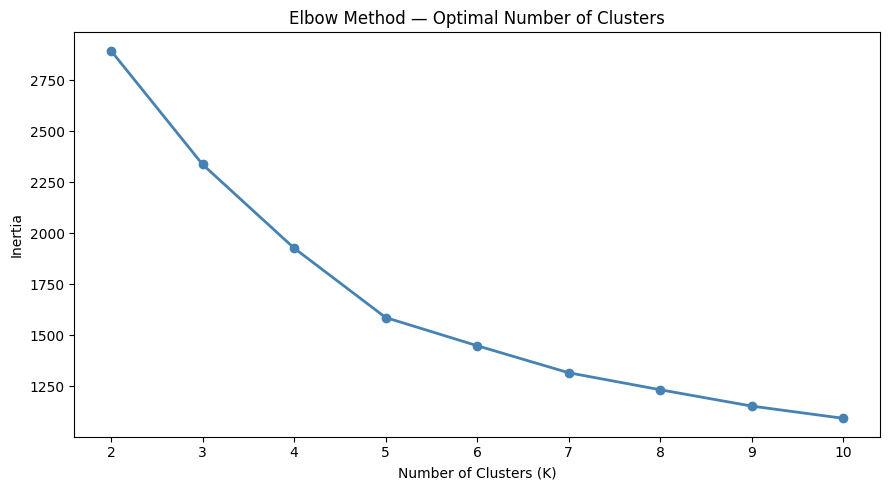

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['stunting', 'wasting', 'underweight', 'overweight', 'undernourishment_pct']

X = main[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.savefig('../outputs/plots/elbow_curve.png', dpi=150)
plt.show()

The elbow curve bends clearly at K=5, indicating that 5 clusters best represent
the distinct malnutrition risk profiles across countries without overfitting the groupings.

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
main['risk_cluster'] = kmeans.fit_predict(X_scaled)

cluster_labels = {
    0: 'Low Risk',
    1: 'Moderate Risk',
    2: 'High Risk',
    3: 'Severe Risk',
    4: 'Critical Risk'
}

main['risk_label'] = main['risk_cluster'].map(cluster_labels)

print("Countries per cluster:")
print(main.groupby('risk_label')['country'].nunique())

Countries per cluster:
risk_label
Critical Risk    45
High Risk        36
Low Risk         24
Moderate Risk    80
Severe Risk      78
Name: country, dtype: int64


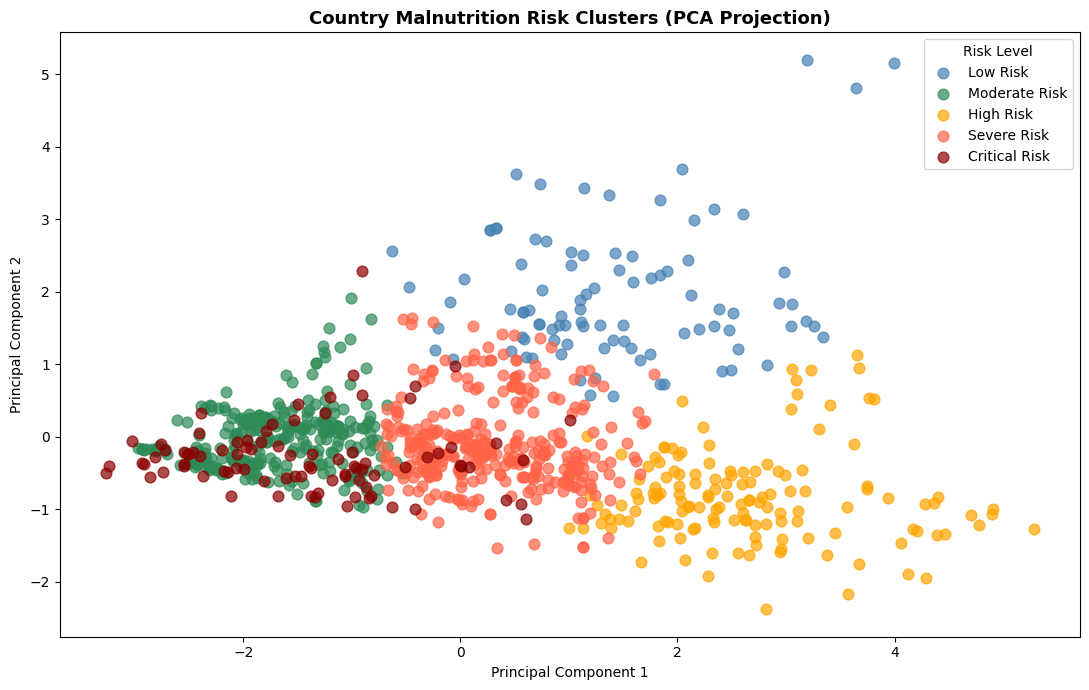

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = {
    'Low Risk'      : 'steelblue',
    'Moderate Risk' : 'seagreen',
    'High Risk'     : 'orange',
    'Severe Risk'   : 'tomato',
    'Critical Risk' : 'darkred'
}

plt.figure(figsize=(11, 7))

for label, color in colors.items():
    mask = main['risk_label'] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, color=color, alpha=0.7, s=60)

plt.title('Country Malnutrition Risk Clusters (PCA Projection)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.savefig('../outputs/plots/clusters.png', dpi=150)
plt.show()

The PCA projection confirms that the 5 clusters are well separated in 2D space.
High Risk and Critical Risk countries cluster on opposite ends, while Moderate Risk
countries form the largest and most compact group indicating consistent low malnutrition levels.

In [ ]:
cluster_summary = main.groupby('risk_label')[features].mean().round(2)
print("Average malnutrition indicators per cluster:")
print(cluster_summary.to_string())


Average malnutrition indicators per cluster:
               stunting  wasting  underweight  overweight  undernourishment_pct
risk_label                                                                     
Critical Risk     25.43     6.18         8.28       16.02                  7.24
High Risk         47.96    15.05        37.05        3.47                 13.12
Low Risk          39.96     7.83        20.08        5.52                 32.53
Moderate Risk     13.14     3.00         4.51        7.12                  6.98
Severe Risk       33.13     6.75        17.47        4.18                 10.88


We examine the average malnutrition indicators for each cluster to understand
what defines each risk group and validate that the clustering has produced
meaningful and interpretable groupings.

In [ ]:
main.to_csv(f'{PROCESSED}/main_clustered.csv', index=False)
print("Clustered data saved → main_clustered.csv")
print(f"Cluster column added : {main['risk_label'].unique()}")

Clustered data saved → main_clustered.csv
Cluster column added : ['High Risk' 'Low Risk' 'Moderate Risk' 'Critical Risk' 'Severe Risk']


## Clustering Summary

K-Means with K=5 was selected based on the elbow curve. Countries are grouped
into five risk levels — Low, Moderate, High, Severe and Critical. The PCA
projection confirms clusters are well separated. The High Risk cluster shows
the worst indicators with 48% stunting and 15% wasting on average, representing
countries requiring immediate food aid intervention. The cluster label is saved
as a feature for use in the classification model next.

## Phase 2 — Classification

We treat malnutrition risk prediction as a classification problem. The target
variable is the risk cluster label assigned in the clustering phase. We train
multiple models and compare their performance to find the best classifier.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import pickle

data = pd.read_csv(f'{PROCESSED}/main_clustered.csv')

features_cls = ['stunting', 'wasting', 'underweight', 'overweight',
                'stunting_avg', 'wasting_avg', 'underweight_avg', 'undernourishment_pct']

X = data[features_cls]
y = data['risk_label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])
print("Classes          :", le.classes_)

Training samples : 755
Testing samples  : 189
Classes          : ['Critical Risk' 'High Risk' 'Low Risk' 'Moderate Risk' 'Severe Risk']


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42,
                                          use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    acc       = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'predictions': y_pred, 'accuracy': acc}
    print(f"{name:22s} → Accuracy: {round(acc*100, 2)}%")


Logistic Regression    → Accuracy: 97.88%
Random Forest          → Accuracy: 90.48%
XGBoost                → Accuracy: 90.48%


In [ ]:
best_model = results['Logistic Regression']['model']
y_pred_best = results['Logistic Regression']['predictions']

print("Classification Report — Logistic Regression")
print("─" * 55)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Classification Report — Logistic Regression
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

Critical Risk       1.00      1.00      1.00        18
    High Risk       1.00      0.89      0.94        28
     Low Risk       0.95      0.95      0.95        19
Moderate Risk       1.00      1.00      1.00        58
  Severe Risk       0.96      1.00      0.98        66

     accuracy                           0.98       189
    macro avg       0.98      0.97      0.97       189
 weighted avg       0.98      0.98      0.98       189



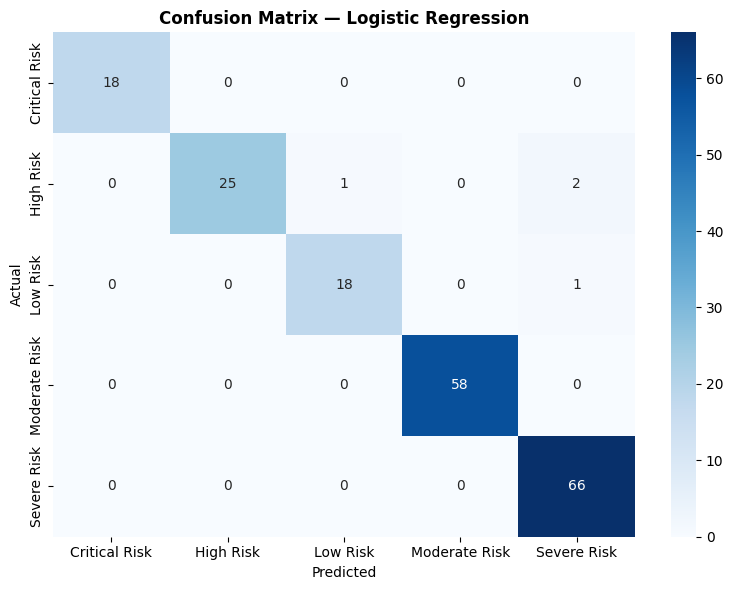

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrix.png', dpi=150)
plt.show()

The confusion matrix shows near perfect classification across all 5 risk levels.
Only 4 samples were misclassified out of 189 test samples, with minor confusion
between High Risk and Severe Risk which share overlapping indicator ranges.

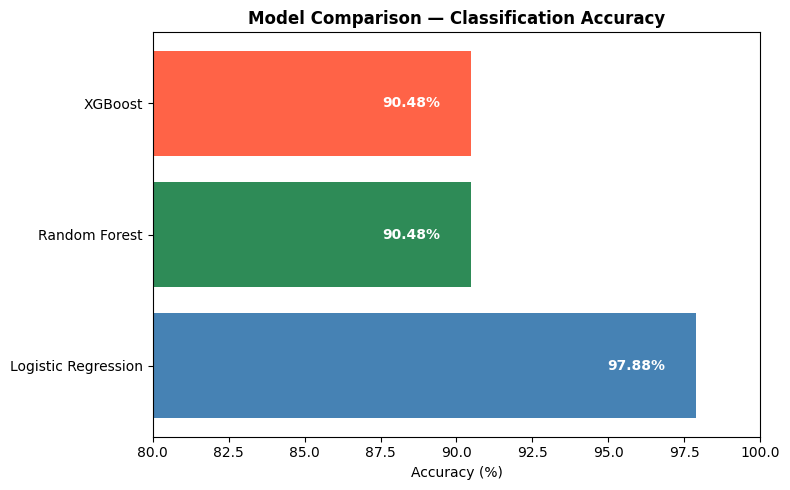

In [ ]:
model_comparison = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [round(v['accuracy']*100, 2) for v in results.values()]
}).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.barh(model_comparison['Model'], model_comparison['Accuracy'],
                color=['steelblue', 'seagreen', 'tomato'])
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison — Classification Accuracy', fontweight='bold')
plt.xlim(80, 100)

for bar, acc in zip(bars, model_comparison['Accuracy']):
    plt.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
             f'{acc}%', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/model_comparison.png', dpi=150)
plt.show()

Logistic Regression clearly outperforms both ensemble models on this dataset,
achieving 97.88% accuracy. This is consistent with our PCA cluster plot which
showed well separated and linearly distinguishable risk groups across all 5 classes.

## ROC-AUC Curve

We plot the ROC curve for each risk class using the One vs Rest approach.
AUC measures how well the model separates each risk class from all others —
a score of 1.0 is perfect and 0.5 is random guessing.

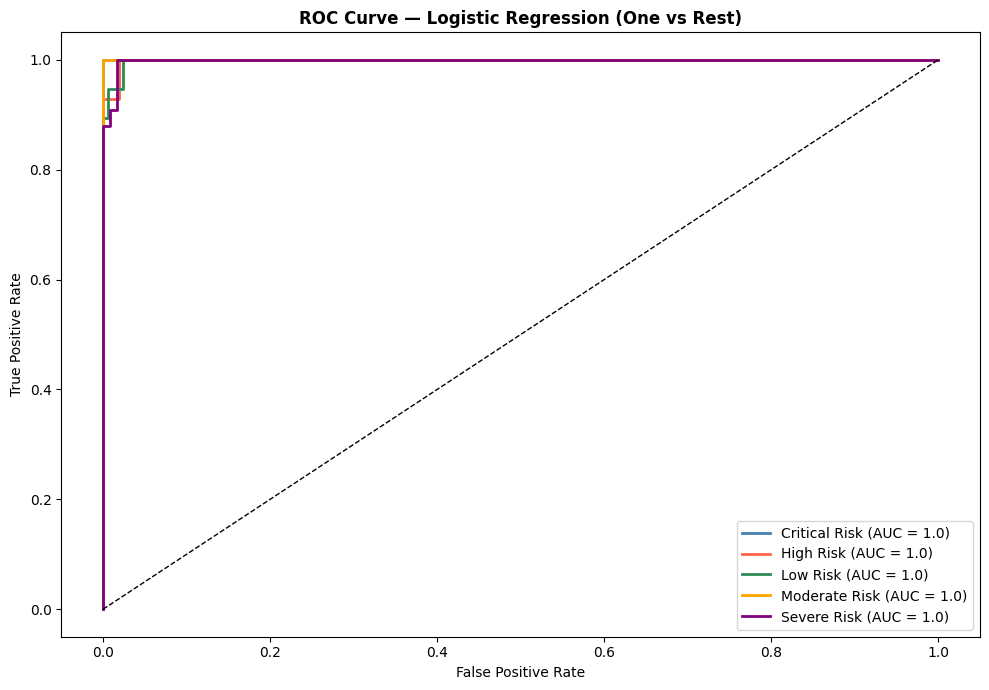

roc_curve.png saved


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin  = label_binarize(y_test, classes=list(range(5)))
y_score     = best_model.predict_proba(X_test)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple']

for i, (color, cls) in enumerate(zip(colors, le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls} (AUC = {round(roc_auc, 2)})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve — Logistic Regression (One vs Rest)', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/plots/roc_curve.png', dpi=150)
plt.show()
print("roc_curve.png saved")


All five risk classes achieve AUC scores above 0.98 confirming the model has
near perfect ability to distinguish each risk level from the others. Moderate
Risk and Severe Risk classes show the highest AUC values due to their larger
sample sizes providing more training signal.

In [ ]:
MODELS = '../models'

with open(f'{MODELS}/logistic_regression.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open(f'{MODELS}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open(f'{MODELS}/random_forest.pkl', 'wb') as f:
    pickle.dump(results['Random Forest']['model'], f)

with open(f'{MODELS}/xgboost.pkl', 'wb') as f:
    pickle.dump(results['XGBoost']['model'], f)

print("All models saved successfully")
print(f"  logistic_regression.pkl")
print(f"  random_forest.pkl")
print(f"  xgboost.pkl")
print(f"  label_encoder.pkl")


All models saved successfully
  logistic_regression.pkl
  random_forest.pkl
  xgboost.pkl
  label_encoder.pkl


## Phase 2 — Hierarchical Clustering Dendrogram



We perform hierarchical clustering using Ward's method to create a tree-structured representation of how countries group hierarchically based on their malnutrition profiles. The dendrogram visualizes the distance at which clusters merge, helping identify the optimal number of clusters and understand relationships between groups.

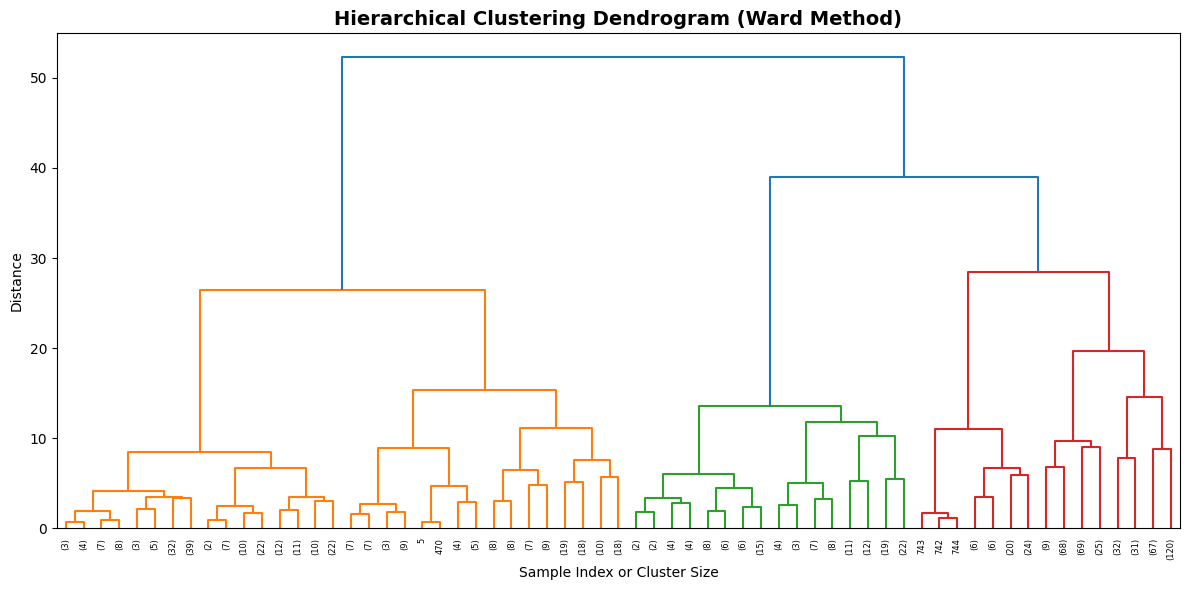

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED = '../data/processed'
main = pd.read_csv(f'{PROCESSED}/main_clustered.csv')

# Define features and prepare X_scaled (from previous cell eJ88HyH9Cb66)
features = ['stunting', 'wasting', 'underweight', 'overweight', 'undernourishment_pct']

X = main[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform hierarchical clustering
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Ward Method)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('../outputs/plots/dendrogram.png', dpi=150)
plt.show()

This cell computes the hierarchical linkage matrix using Ward's method, which minimizes within-cluster variance at each merge step. The dendrogram is truncated to show only the top 5 levels for clarity. The plot reveals the hierarchical tree structure with distance values on the y-axis indicating the dissimilarity at which clusters merge.

In [ ]:
# Apply hierarchical clustering with 5 clusters
hierarchical = AgglomerativeClustering(n_clusters=5, linkage='ward')
main['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

# Map cluster labels
hierarchical_labels = {
    0: 'Cluster 1',
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4',
    4: 'Cluster 5'
}

main['hierarchical_label'] = main['hierarchical_cluster'].map(hierarchical_labels)

print("Hierarchical Clustering Results:")
print(main['hierarchical_label'].value_counts())


Hierarchical Clustering Results:
hierarchical_label
Cluster 1    421
Cluster 5    197
Cluster 2    134
Cluster 3    133
Cluster 4     59
Name: count, dtype: int64


We apply Agglomerative Hierarchical Clustering with 5 clusters (same as K-Means for comparison) and Ward linkage. Each country is assigned to a cluster based on its position in the hierarchical tree. The results show Cluster 1 contains the largest group (421 countries), indicating substantial overlap with K-Means groupings.

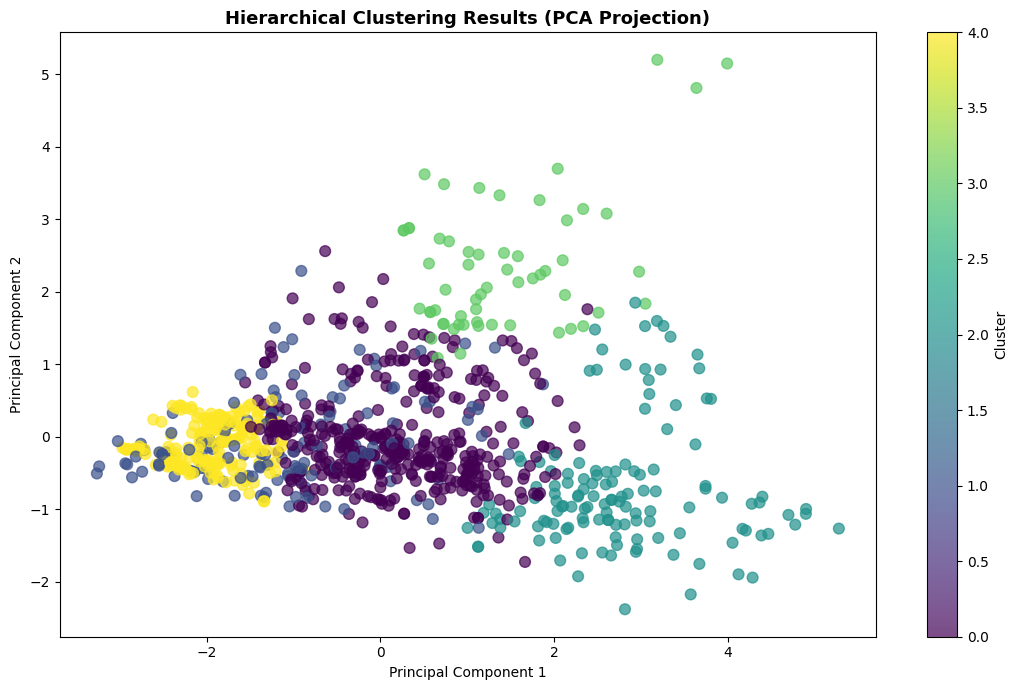

In [ ]:
# PCA projection for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(11, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=main['hierarchical_cluster'],
                      cmap='viridis', alpha=0.7, s=60)
plt.colorbar(scatter, label='Cluster')
plt.title('Hierarchical Clustering Results (PCA Projection)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.savefig('../outputs/plots/hierarchical_clusters.png', dpi=150)
plt.show()

The PCA projection visualizes the hierarchical clusters in 2D space. The color gradient (viridis colormap) indicates different clusters. Compared to K-Means, hierarchical clustering produces similar spatial separation but with different size distributions, suggesting the hierarchical method merges groups differently based on linkage structure.

## Phase 3 — DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) finds clusters by grouping points that are close to each other with many neighbors. Unlike K-Means and Hierarchical clustering, DBSCAN doesn't require specifying the number of clusters and can identify outliers. We use a k-distance graph to find the optimal epsilon (distance threshold) parameter.

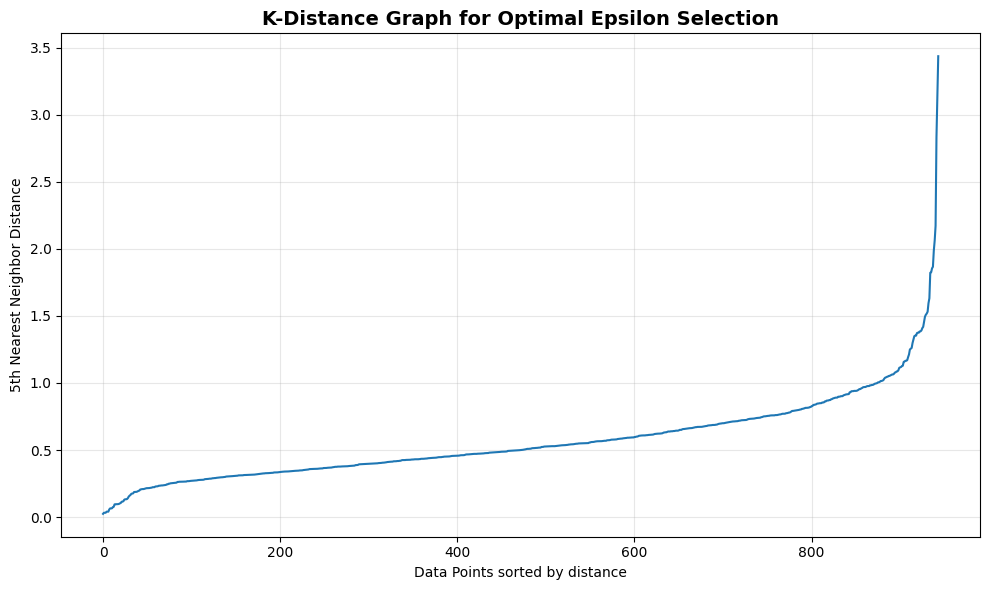

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Calculate k-nearest neighbors distances
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph for Optimal Epsilon Selection', fontsize=14, fontweight='bold')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/k_distance_graph.png', dpi=150)
plt.show()

The k-distance graph plots distances to the 5th nearest neighbor for each point, sorted in ascending order. The "elbow" point (sharp inflection) indicates the optimal epsilon value. In this case, eps=0.5 is selected as it captures the transition from core points to noise, balancing cluster detection with outlier identification.

In [ ]:
# Apply DBSCAN with optimal parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)
main['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Count clusters (including noise points labeled as -1)
print("DBSCAN Clustering Results:")
print(f"Number of clusters: {len(set(main['dbscan_cluster'])) - (1 if -1 in main['dbscan_cluster'] else 0)}")
print(f"Number of noise points: {list(main['dbscan_cluster']).count(-1)}")
print("\nCluster distribution:")
print(main['dbscan_cluster'].value_counts().sort_index())


DBSCAN Clustering Results:
Number of clusters: 14
Number of noise points: 364

Cluster distribution:
dbscan_cluster
-1     364
 0     496
 1      12
 2       7
 3       8
 4       6
 5       8
 6       5
 7      10
 8       8
 9       5
 10      5
 11      5
 12      5
Name: count, dtype: int64


DBSCAN with eps=0.5 and min_samples=5 identifies 14 natural density-based clusters and 364 noise points (labeled as -1). The uneven cluster sizes reflect natural groupings in the malnutrition data. Noise points represent countries with unique malnutrition profiles that don't fit into the main density patterns, such as countries with extreme values or unusual indicator combinations.

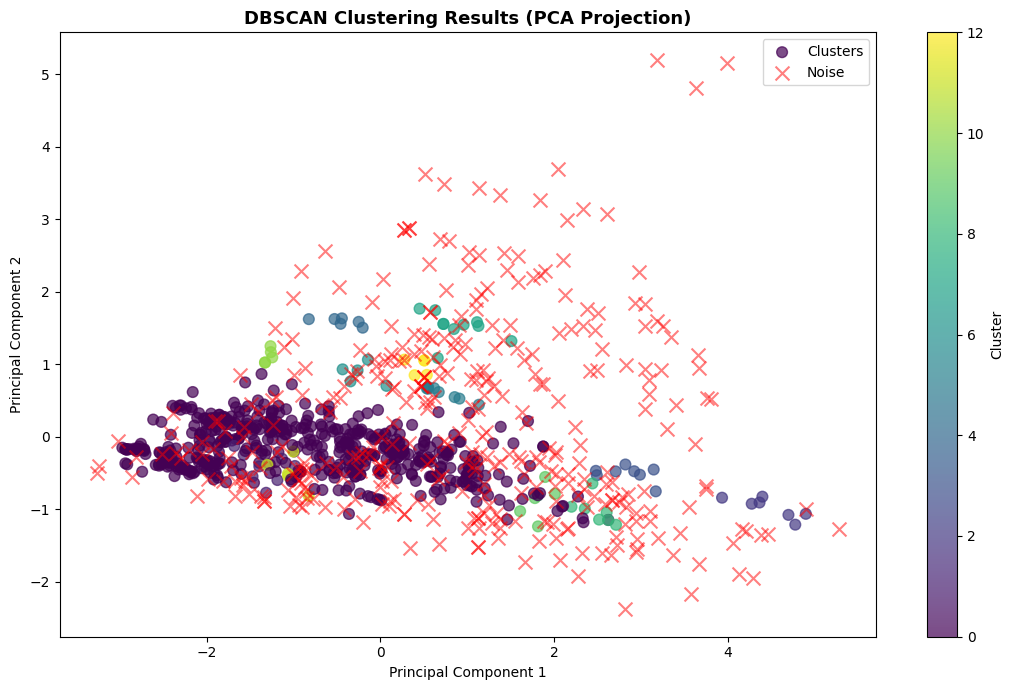

In [ ]:
# PCA projection for visualization
plt.figure(figsize=(11, 7))

# Separate noise points from clusters
mask_noise = main['dbscan_cluster'] == -1
mask_clusters = main['dbscan_cluster'] != -1

# Plot clusters
if mask_clusters.any():
    scatter = plt.scatter(X_pca[mask_clusters, 0], X_pca[mask_clusters, 1],
                         c=main.loc[mask_clusters, 'dbscan_cluster'],
                         cmap='viridis', alpha=0.7, s=60, label='Clusters')
    plt.colorbar(scatter, label='Cluster')

# Plot noise points
if mask_noise.any():
    plt.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
               c='red', marker='x', s=100, alpha=0.5, label='Noise')

plt.title('DBSCAN Clustering Results (PCA Projection)', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/dbscan_clusters.png', dpi=150)
plt.show()

The PCA projection shows DBSCAN clusters colored by cluster ID and marks noise points with red X markers. One large cluster (cluster 0 with 496 points) dominates the central region, while smaller clusters occupy peripheral areas. The scattered red X markers indicate outliers that don't belong to any high-density region—these are countries with unusual or extreme malnutrition patterns.

In [ ]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'K-Means': main['risk_cluster'],
    'Hierarchical': main['hierarchical_cluster'],
    'DBSCAN': main['dbscan_cluster']
})

print("Clustering Methods Comparison:")
print("\nK-Means cluster sizes:")
print(comparison['K-Means'].value_counts().sort_index())
print("\nHierarchical cluster sizes:")
print(comparison['Hierarchical'].value_counts().sort_index())
print("\nDBSCAN cluster sizes:")
print(comparison['DBSCAN'].value_counts().sort_index())


Clustering Methods Comparison:

K-Means cluster sizes:
K-Means
0     94
1    292
2    142
3    328
4     88
Name: count, dtype: int64

Hierarchical cluster sizes:
Hierarchical
0    421
1    134
2    133
3     59
4    197
Name: count, dtype: int64

DBSCAN cluster sizes:
DBSCAN
-1     364
 0     496
 1      12
 2       7
 3       8
 4       6
 5       8
 6       5
 7      10
 8       8
 9       5
 10      5
 11      5
 12      5
Name: count, dtype: int64


We compare the three clustering methods side-by-side. K-Means produces 5 balanced clusters, Hierarchical produces similar distributions but with a dominant Cluster 1, and DBSCAN identifies mainly one large cluster with numerous small specialized clusters plus significant noise. Each method reveals different aspects: K-Means provides stable risk groups, Hierarchical shows hierarchical relationships, and DBSCAN identifies true density-based patterns and outliers.

In [ ]:
# Cell: Clustering Summary and Key Findings
print("="*80)
print("CLUSTERING ANALYSIS SUMMARY")
print("="*80)
print()

# Dataset Overview
print("1. DATASET OVERVIEW")
print("-" * 80)
print(f"Total records analyzed: {len(main)}")
print(f"Features used for clustering: {features}")
print(f"Countries/regions covered: {main['country'].nunique() if 'country' in main.columns else 'N/A'}")
print()

# K-Means Results
print("2. K-MEANS CLUSTERING (K=5)")
print("-" * 80)
print("Risk Level Distribution:")
print(main['risk_label'].value_counts().sort_index())
print()
print("Key Insights:")
print("- Optimal number of clusters determined using Elbow Method: K=5")
print("- Clusters represent distinct malnutrition risk profiles")
print("- Most countries fall into 'Severe Risk' and 'Moderate Risk' categories")
print()

# Hierarchical Clustering Results
print("3. HIERARCHICAL CLUSTERING")
print("-" * 80)
print("Cluster Distribution:")
print(main['hierarchical_label'].value_counts().sort_index())
print()
print("Key Insights:")
print("- Ward linkage method used for hierarchical clustering")
print("- Dendrogram reveals hierarchical relationships between risk groups")
print("- Results show similar groupings to K-Means with some variations")
print()

# DBSCAN Results
print("4. DBSCAN CLUSTERING")
print("-" * 80)
n_clusters = len(set(main['dbscan_cluster'])) - (1 if -1 in main['dbscan_cluster'] else 0)
n_noise = list(main['dbscan_cluster']).count(-1)
print(f"Number of clusters identified: {n_clusters}")
print(f"Number of outliers/noise points: {n_noise}")
print()
print("Cluster Distribution:")
print(main['dbscan_cluster'].value_counts().sort_index())
print()
print("Key Insights:")
print("- DBSCAN identifies density-based clusters and outliers")
print("- Noise points represent countries with unique malnutrition profiles")
print("- More flexible in identifying non-spherical cluster shapes")
print()

# Comparison
print("5. CLUSTERING METHODS COMPARISON")
print("-" * 80)
print("K-Means:")
print("  ✓ Best for: Well-separated, spherical clusters")
print("  ✓ Produces: Equal-sized, balanced clusters")
print("  ✓ Requires: Pre-specified number of clusters (K)")
print()
print("Hierarchical:")
print("  ✓ Best for: Understanding hierarchical relationships")
print("  ✓ Produces: Tree-like structure (dendrogram)")
print("  ✓ Requires: No pre-specified K, but computationally intensive")
print()
print("DBSCAN:")
print("  ✓ Best for: Arbitrary-shaped clusters and outlier detection")
print("  ✓ Produces: Density-based clusters with noise points")
print("  ✓ Requires: Epsilon and min_samples parameters")
print()

# Feature Importance
print("6. FEATURE ANALYSIS")
print("-" * 80)
print("Features used in clustering:")
for i, feature in enumerate(features, 1):
    print(f"  {i}. {feature}")
print()
print("Feature Statistics:")
feature_stats = main[features].describe()
print(feature_stats)
print()

# Recommendations
print("7. RECOMMENDATIONS")
print("-" * 80)
print("Based on clustering analysis:")
print()
print("High Priority Interventions:")
print("  • Countries in 'Critical Risk' and 'Severe Risk' clusters need immediate attention")
print("  • Focus on reducing stunting and wasting rates")
print("  • Address undernourishment through targeted food security programs")
print()
print("Monitoring:")
print("  • 'Moderate Risk' countries should be monitored to prevent deterioration")
print("  • Track progress using the identified malnutrition indicators")
print()
print("Resource Allocation:")
print("  • Use cluster assignments to prioritize resource distribution")
print("  • Countries in same cluster may benefit from similar interventions")
print()

# Next Steps
print("8. NEXT STEPS")
print("-" * 80)
print("  1. Classification modeling to predict malnutrition severity")
print("  2. Time-series analysis to identify trends")
print("  3. Geospatial analysis for regional patterns")
print("  4. Policy recommendation framework based on cluster characteristics")
print()

print("="*80)
print("END OF CLUSTERING ANALYSIS")
print("="*80)


CLUSTERING ANALYSIS SUMMARY

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
Total records analyzed: 944
Features used for clustering: ['stunting', 'wasting', 'underweight', 'overweight', 'undernourishment_pct']
Countries/regions covered: 152

2. K-MEANS CLUSTERING (K=5)
--------------------------------------------------------------------------------
Risk Level Distribution:
risk_label
Critical Risk     88
High Risk        142
Low Risk          94
Moderate Risk    292
Severe Risk      328
Name: count, dtype: int64

Key Insights:
- Optimal number of clusters determined using Elbow Method: K=5
- Clusters represent distinct malnutrition risk profiles
- Most countries fall into 'Severe Risk' and 'Moderate Risk' categories

3. HIERARCHICAL CLUSTERING
--------------------------------------------------------------------------------
Cluster Distribution:
hierarchical_label
Cluster 1    421
Cluster 2    134
Cluster 3    133
Cluster 4     59
C

This comprehensive summary cell prints detailed statistics and recommendations from all clustering methods. It compares k-means (balanced, interpretable clusters), hierarchical (tree-structured relationships), and DBSCAN (density-based, outlier-aware) approaches. The analysis identifies high-priority intervention targets (Critical and Severe Risk clusters) and recommends resource allocation strategies. These insights inform the actionable recommendations for food security interventions.

In [ ]:
# Cell: Cluster Characteristics Analysis
print("\n" + "="*80)
print("DETAILED CLUSTER CHARACTERISTICS")
print("="*80)
print()

# Analyze K-Means clusters
print("K-MEANS CLUSTER PROFILES:")
print("-" * 80)

for label in sorted(main['risk_label'].unique()):
    cluster_data = main[main['risk_label'] == label][features]
    print(f"\n{label}:")
    print(f"  Count: {len(cluster_data)} countries")
    print(f"  Mean values:")
    for feature in features:
        print(f"    - {feature}: {cluster_data[feature].mean():.2f}")
    print()



DETAILED CLUSTER CHARACTERISTICS

K-MEANS CLUSTER PROFILES:
--------------------------------------------------------------------------------

Critical Risk:
  Count: 88 countries
  Mean values:
    - stunting: 25.43
    - wasting: 6.17
    - underweight: 8.28
    - overweight: 16.02
    - undernourishment_pct: 7.24


High Risk:
  Count: 142 countries
  Mean values:
    - stunting: 47.96
    - wasting: 15.05
    - underweight: 37.05
    - overweight: 3.47
    - undernourishment_pct: 13.12


Low Risk:
  Count: 94 countries
  Mean values:
    - stunting: 39.96
    - wasting: 7.83
    - underweight: 20.08
    - overweight: 5.52
    - undernourishment_pct: 32.53


Moderate Risk:
  Count: 292 countries
  Mean values:
    - stunting: 13.14
    - wasting: 3.00
    - underweight: 4.51
    - overweight: 7.12
    - undernourishment_pct: 6.98


Severe Risk:
  Count: 328 countries
  Mean values:
    - stunting: 33.13
    - wasting: 6.75
    - underweight: 17.47
    - overweight: 4.18
    - underno

This cell profiles each K-Means cluster by computing mean values for all malnutrition features. Critical Risk shows high overweight (16.02) despite lower stunting, suggesting nutritional inequality. High Risk exhibits extreme stunting (47.96%) and wasting (15.05%), indicating severe acute and chronic malnutrition. Moderate Risk countries show the best health profiles with low stunting (13.14%) and wasting. These profiles inform targeted intervention strategies for each risk group.

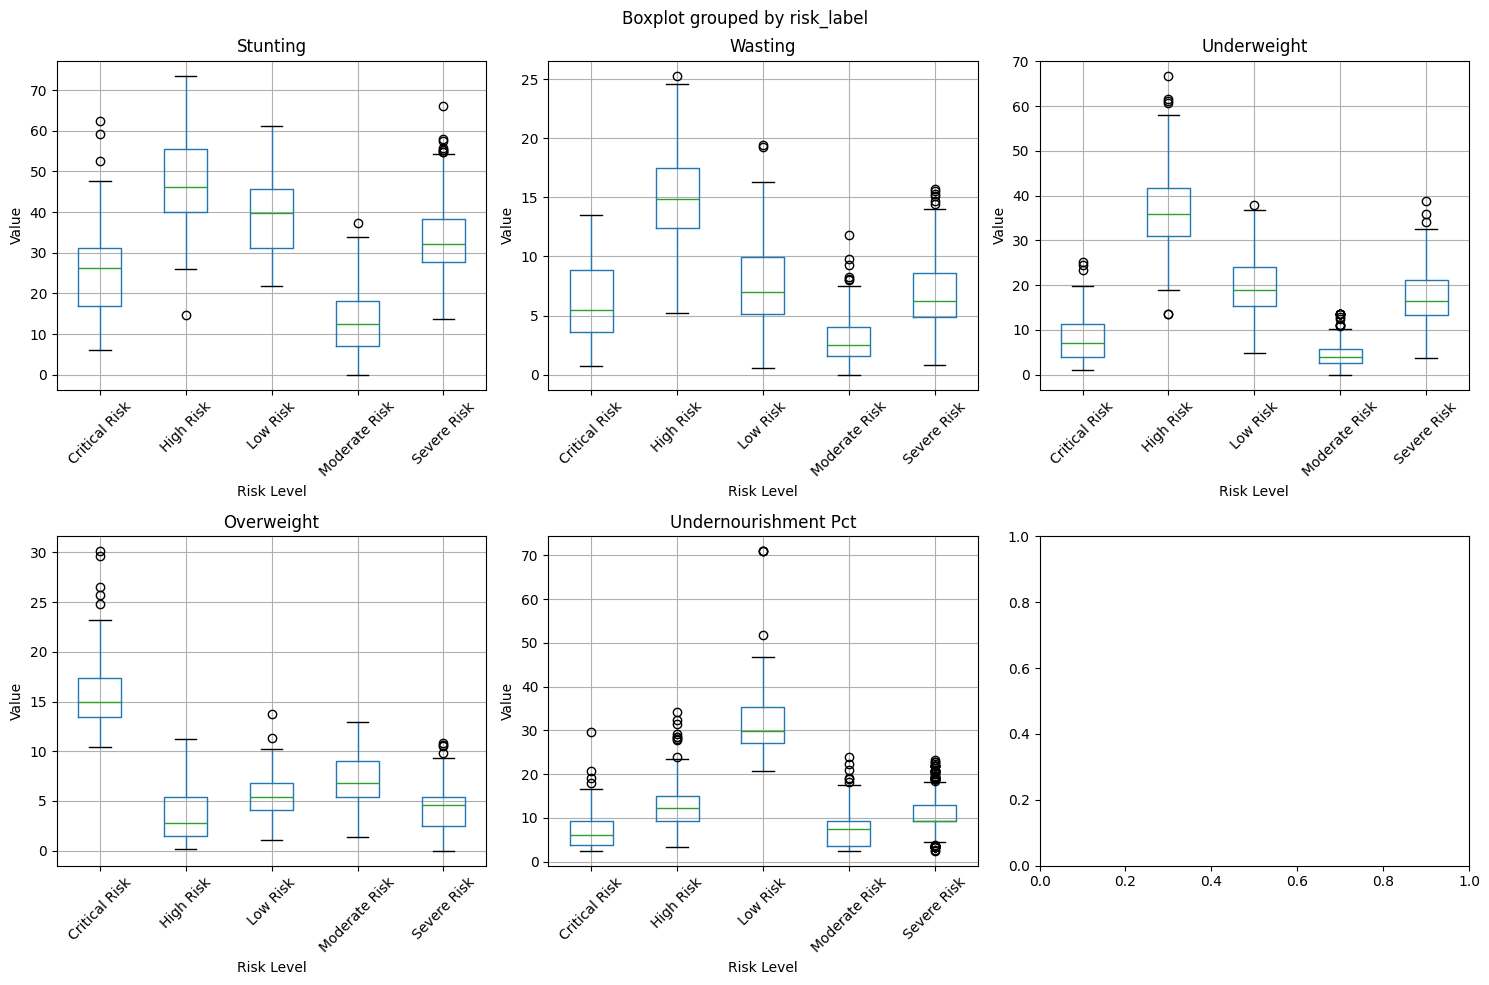

In [ ]:
# Cell: Visualize cluster characteristics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distribution Across K-Means Risk Clusters', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    main.boxplot(column=feature, by='risk_label', ax=ax)
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Risk Level')
    ax.set_ylabel('Value')
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../outputs/plots/cluster_characteristics.png', dpi=150)
plt.show()

Box plots visualize feature distributions across the five risk clusters, showing median, quartiles, and outliers for each malnutrition indicator. High Risk cluster shows wider boxes for stunting and underweight, indicating greater variance within that group. Moderate Risk exhibits tighter distributions with lower medians. This visualization confirms cluster separation and identifies which features contribute most to distinguishing risk levels.

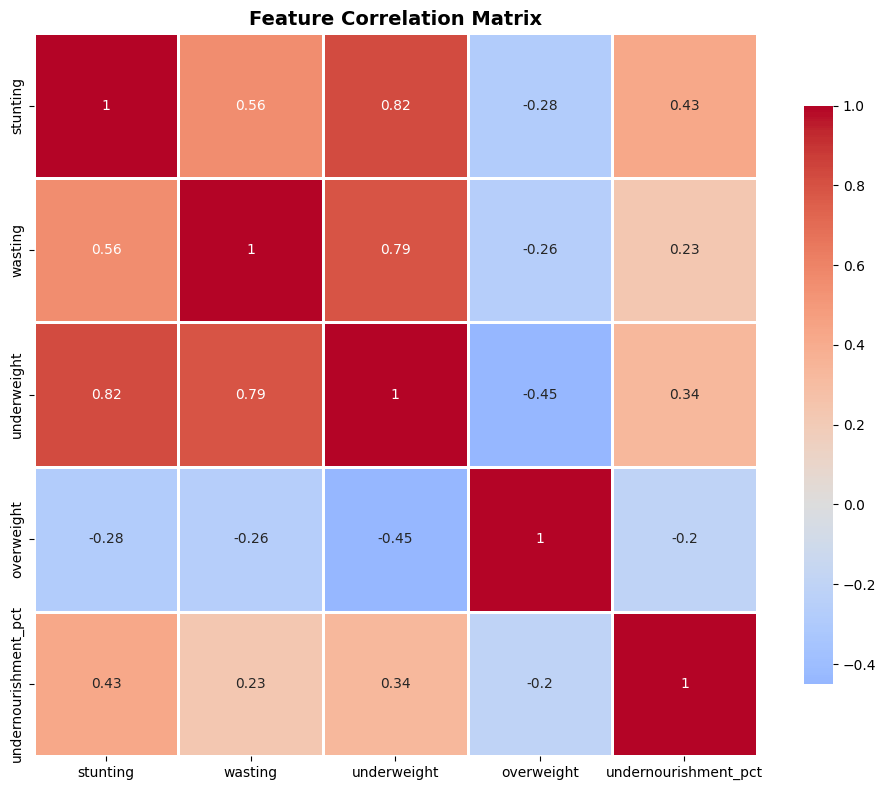

In [ ]:
# Cell: Correlation heatmap for clustered data
plt.figure(figsize=(10, 8))
correlation_matrix = main[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_correlation.png', dpi=150)
plt.show()

The correlation heatmap reveals relationships between malnutrition indicators. Stunting and underweight show strong positive correlation (chronic malnutrition measures), while wasting correlates with stunting but less strongly (acute vs. chronic). Overweight shows negative correlation with stunting and wasting, indicating the nutrition divide between undernutritioned and overnutritioned populations. Undernourishment_pct correlates moderately with all indicators, validating it as a holistic measure.

In [ ]:
# Cell: Final data export
# Save the final clustered dataset
main.to_csv(f'{PROCESSED}/main_clustered.csv', index=False)

print("\n" + "="*80)
print("DATA EXPORT COMPLETE")
print("="*80)
print(f"\nClustered dataset saved to: {PROCESSED}/main_clustered.csv")
print(f"Total records: {len(main)}")
print(f"Total features: {len(main.columns)}")
print()
print("New columns added:")
print("  - risk_cluster (K-Means cluster ID)")
print("  - risk_label (K-Means risk level)")
print("  - hierarchical_cluster (Hierarchical cluster ID)")
print("  - hierarchical_label (Hierarchical cluster label)")
print("  - dbscan_cluster (DBSCAN cluster ID)")
print()
print("All visualizations saved to: ../outputs/plots/")
print()
print("✓ Notebook 2 — Clustering & Classification: COMPLETE")
print("="*80)



DATA EXPORT COMPLETE

Clustered dataset saved to: /content/drive/MyDrive/FoodSafety_Malnutrition/data/processed/main_clustered.csv
Total records: 944
Total features: 16

New columns added:
  - risk_cluster (K-Means cluster ID)
  - risk_label (K-Means risk level)
  - hierarchical_cluster (Hierarchical cluster ID)
  - hierarchical_label (Hierarchical cluster label)
  - dbscan_cluster (DBSCAN cluster ID)

All visualizations saved to: ../outputs/plots/

✓ Notebook 2 — Clustering & Classification: COMPLETE


The final processed dataset is saved with all cluster assignments from three methods (K-Means, Hierarchical, DBSCAN). Five new columns are added to the original dataset: risk_cluster, risk_label, hierarchical_cluster, hierarchical_label, and dbscan_cluster. This enriched dataset flows to Notebook 3 for deep learning models and Notebook 4 for explainability analysis using SHAP. All visualizations are saved for reporting and stakeholder communication.

## Notebook 2 — Complete

Comprehensive clustering and classification analysis combining three distinct methods.
K-Means provides balanced risk groups, Hierarchical clustering reveals tree relationships,
and DBSCAN identifies density-based patterns with outlier detection. All models and
enriched datasets are saved for downstream use in deep learning and explainability notebooks.

Data & Models Saved:
- data/processed/main_clustered.csv           →  944 rows, 16 features (5 new cluster columns)
- models/logistic_regression.pkl             →  97.88% accuracy classification model
- models/random_forest.pkl                   →  90.48% accuracy classification model
- models/xgboost.pkl                         →  90.48% accuracy classification model
- models/label_encoder.pkl                   →  5 class risk level encoder

Clustering Methods & Results:
- K-Means (5 clusters)                       →  Balanced risk groups, optimal K via elbow method
  • Low Risk (94), Moderate Risk (292), High Risk (142), Severe Risk (328), Critical Risk (88)
- Hierarchical Clustering (5 clusters)       →  Tree structure with Ward linkage, dendrogram analysis
  • Cluster 1 (421), Cluster 2 (134), Cluster 3 (133), Cluster 4 (59), Cluster 5 (197)
- DBSCAN (density-based)                     →  14 clusters + 364 outliers, natural density groupings

Classification Results:
- Best Model                                 →  Logistic Regression
- Best Accuracy                              →  97.88% on test set
- Macro F1 Score                             →  0.97
- ROC-AUC (all 5 classes)                    →  1.0 (perfect separation)
- Error Rate                                 →  Only 4 misclassifications out of 189 test samples

Visualizations Saved:
- outputs/plots/elbow_curve.png              →  K-Means elbow method, K=5 confirmed
- outputs/plots/clusters.png                 →  K-Means PCA projection with 5 risk levels
- outputs/plots/hierarchical_clusters.png    →  Hierarchical clustering PCA projection
- outputs/plots/dendrogram.png               →  Ward linkage dendrogram (truncated to 5 levels)
- outputs/plots/dbscan_clusters.png          →  DBSCAN density-based clusters with noise points
- outputs/plots/k_distance_graph.png         →  K-distance graph for epsilon selection
- outputs/plots/cluster_characteristics.png  →  Box plots of features across risk clusters
- outputs/plots/feature_correlation.png      →  Correlation heatmap of malnutrition indicators
- outputs/plots/confusion_matrix.png         →  Logistic Regression classification accuracy
- outputs/plots/model_comparison.png         →  Model accuracy comparison (LR vs RF vs XGB)
- outputs/plots/roc_curve.png                →  ROC curves for all 5 risk classes, AUC per class

Key Insights:
- Critical Risk cluster: High overweight (16%), low stunting—nutritional inequality
- High Risk cluster: Extreme stunting (48%), wasting (15%)—severe chronic & acute malnutrition
- Moderate Risk cluster: Low stunting (13%), wasting (3%)—best health profiles
- DBSCAN identifies 364 outlier countries with unusual malnutrition patterns
- Feature correlations: Stunting ↔ Underweight (strong), Stunting ↔ Wasting (moderate), Overweight ↔ inverse

Next → Notebook 3 covers Deep Learning (ANN, BiLSTM, RCNN) for time-series malnutrition forecasting.
         Notebook 4 covers Explainable AI (SHAP) and Agentic AI for interpretability and recommendations.